In [202]:
# Step 1: Import libraries
import pandas as pd
import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Step 2: Load raw dataset
file_path = "//Users/druvitha/Downloads/Peoples_Climate_Vote_Database_2024.csv" # adjust if needed
df_raw = pd.read_csv(file_path)

print("Raw dataset loaded successfully!")
print("Shape:", df_raw.shape)
df_raw.head()


Raw dataset loaded successfully!
Shape: (45784, 17)


,Column1,ID,CID,QID,RID,EID,AID,Country,Question Text,Question Text (Short),Response,Education,Age,Weighted Mean,Cat ID,Category,Question Context
0,60,60,1,13,1,1,1,Global,Should countries work together on climate chan...,Countries working together,Yes - they should work together despite their ...,All Education,All Ages,86.0,4,Peoples' call for collaboration,Climate change is a global problem that requir...
1,61,61,1,13,2,1,1,Global,Should countries work together on climate chan...,Countries working together,No - they should work separately,All Education,All Ages,7.0,4,Peoples' call for collaboration,Climate change is a global problem that requir...
2,62,62,1,13,3,1,1,Global,Should countries work together on climate chan...,Countries working together,It doesn't matter - no country should work on ...,All Education,All Ages,5.0,4,Peoples' call for collaboration,Climate change is a global problem that requir...
3,63,63,1,13,1000,1,1,Global,Should countries work together on climate chan...,Countries working together,Don't know,All Education,All Ages,2.0,4,Peoples' call for collaboration,Climate change is a global problem that requir...
4,273,273,1,13,1,1,2,Global,Should countries work together on climate chan...,Countries working together,Yes - they should work together despite their ...,All Education,Under 18,86.0,4,Peoples' call for collaboration,Climate change is a global problem that requir...


In [203]:
# Step 2: Slim to relevant columns and drop missing percentages


cols_keep = [
    "Country",
    "Education",
    "Age",
    "Question Text (Short)",
    "Response",
    "Weighted Mean",
    "Category",
    "Question Context"
]

df_small = df_raw[cols_keep].copy()

# Keep only rows where the weighted percentage exists
df_small = df_small[~df_small["Weighted Mean"].isna()].copy()

print("df_small shape:", df_small.shape)
df_small.head()



df_small shape: (25523, 8)


,Country,Education,Age,Question Text (Short),Response,Weighted Mean,Category,Question Context
0,Global,All Education,All Ages,Countries working together,Yes - they should work together despite their ...,86.0,Peoples' call for collaboration,Climate change is a global problem that requir...
1,Global,All Education,All Ages,Countries working together,No - they should work separately,7.0,Peoples' call for collaboration,Climate change is a global problem that requir...
2,Global,All Education,All Ages,Countries working together,It doesn't matter - no country should work on ...,5.0,Peoples' call for collaboration,Climate change is a global problem that requir...
3,Global,All Education,All Ages,Countries working together,Don't know,2.0,Peoples' call for collaboration,Climate change is a global problem that requir...
4,Global,All Education,Under 18,Countries working together,Yes - they should work together despite their ...,86.0,Peoples' call for collaboration,Climate change is a global problem that requir...


In [204]:
# Step 3: Create combined Question|Response label
df_small["Q_R"] = df_small["Question Text (Short)"] + " | " + df_small["Response"]

# Step 4.2: Pivot to wide format (one row per Country–Age–Education group)
df_pivot = df_small.pivot_table(
    index=["Country", "Age", "Education"],
    columns="Q_R",
    values="Weighted Mean"
).reset_index()

print("df_pivot shape BEFORE dropping All Ages:", df_pivot.shape)

# Step 4.3: Drop ONLY 'All Ages' groups, keep all Education levels
df_pivot = df_pivot[df_pivot["Age"] != "All Ages"].copy()

print("df_pivot shape AFTER dropping All Ages:", df_pivot.shape)
print("Unique Age values:", df_pivot["Age"].unique())
df_pivot.head()


df_pivot shape BEFORE dropping All Ages: (360, 74)
df_pivot shape AFTER dropping All Ages: (147, 74)
Unique Age values: ['18 to 35' '36 to 59' '60 plus' 'Under 18']


Q_R,Country,Age,Education,Big businesses performance | Don't know,Big businesses performance | Neither well nor badly,Big businesses performance | Somewhat badly,Big businesses performance | Somewhat well,Big businesses performance | Very badly,Big businesses performance | Very well,Countries working together | Don't know,Countries working together | It doesn't matter - no country should work on climate change,Countries working together | No - they should work separately,Countries working together | Yes - they should work together despite their disagreements,Country performance | Don't know,Country performance | Neither well nor badly,Country performance | Somewhat badly,Country performance | Somewhat well,Country performance | Very badly,Country performance | Very well,Effects on big decisions | A little,Effects on big decisions | A lot,Effects on big decisions | Don't know,Effects on big decisions | Not at all,Extreme weather experience | About the same as usual,Extreme weather experience | Better than usual,Extreme weather experience | Don't know,Extreme weather experience | Worse than usual,Protect and restore nature | A little,Protect and restore nature | A lot,Protect and restore nature | Don't know,Protect and restore nature | Not at all,Protection from extreme weather | About the same as now,Protection from extreme weather | Don't know,Protection from extreme weather | Less protection,Protection from extreme weather | More protection,Renewable energy transition | Don't know,Renewable energy transition | Not at all,Renewable energy transition | Slowly,Renewable energy transition | Somewhat quickly,Renewable energy transition | Very quickly,Rich countries helping poor | About the same as now,Rich countries helping poor | Don't know,Rich countries helping poor | Less help,Rich countries helping poor | More help,Strengthening commitments | Don't know,Strengthening commitments | Keep them the same,Strengthening commitments | Strengthen,Strengthening commitments | Weaken,Teaching about climate change | About the same as now,Teaching about climate change | Don't know,Teaching about climate change | Less,Teaching about climate change | More,Thinking about climate change | A few times a year,Thinking about climate change | Daily,Thinking about climate change | Don't know,Thinking about climate change | Never,Thinking about climate change | Weekly,Who has had most impact | Big business,Who has had most impact | Campaigners and activists,Who has had most impact | Don't know,Who has had most impact | Faith and community leaders,Who has had most impact | Government,Who has had most impact | The European Union (EU),Who has had most impact | The United Nations,Worry compared to last year | About the same,Worry compared to last year | Don't know,Worry compared to last year | Less worried,Worry compared to last year | More worried,Worry for next generation | Don't know,Worry for next generation | Extremely,Worry for next generation | Not at all,Worry for next generation | Not very,Worry for next generation | Somewhat,Worry for next generation | Very
0,Afghanistan,18 to 35,All Education,8.0,18.0,10.0,26.0,14.0,24.0,2.0,1.0,4.0,94.0,9.0,20.0,9.0,27.0,17.0,19.0,21.0,71.0,2.0,6.0,26.0,13.0,11.0,50.0,6.0,90.0,2.0,2.0,6.0,2.0,2.0,90.0,7.0,4.0,39.0,11.0,39.0,3.0,0.0,1.0,96.0,8.0,15.0,75.0,2.0,8.0,1.0,2.0,89.0,7.0,49.0,4.0,7.0,33.0,7.0,2.0,26.0,3.0,27.0,0.0,34.0,9.0,2.0,14.0,75.0,4.0,32.0,5.0,1.0,22.0,36.0
1,Afghanistan,36 to 59,All Education,8.0,18.0,11.0,23.0,16.0,23.0,2.0,0.0,4.0,94.0,14.0,23.0,8.0,23.0,17.0,15.0,14.0,75.0,4.0,7.0,18.0,15.0,11.0,55.0,5.0,93.0,2.0,1.0,6.0,1.0,3.0,90.0,14.0,1.0,44.0,9.0,31.0,2.0,0.0,1.0,97.0,9.0,12.0,76.0,2.0,4.0,0.0,1.0,94.0,6.0,63.0,2.0,5.0,24.0,6.0,2.0,35.0,4.0,19.0,0.0,33.0,5.0,1.0,8.0,86.0,5.0,33.0,2.0,2.0,19.0,39.0
6,Algeria,18 to 35,All Education,18.0,41.0,17.0,11.0,12.0,1.0,3.0,1.0,14.0,82.0,7.0,45.0,17.0,14.0,12.0,4.0,25.0,44.0,1.0,30.0,22.0,8.0,1.0,70.0,5.0,93.0,1.0,2.0,6.0,1.0,1.0,93.0,7.0,10.0,10.

In [205]:

# Step 4: Define target column = % who chose "Strengthen"
target_col_raw = "Strengthening commitments | Strengthen"

df_pivot = df_pivot.rename(columns={target_col_raw: "support_strengthen_pct"})
df_pivot = df_pivot[~df_pivot["support_strengthen_pct"].isna()].copy()

print("df_pivot shape after target:", df_pivot.shape)
df_pivot[["Country", "Age", "Education", "support_strengthen_pct"]].head()




df_pivot shape after target: (147, 74)


Q_R,Country,Age,Education,support_strengthen_pct
0,Afghanistan,18 to 35,All Education,75.0
1,Afghanistan,36 to 59,All Education,76.0
6,Algeria,18 to 35,All Education,76.0
7,Algeria,36 to 59,All Education,73.0
10,Argentina,18 to 35,All Education,84.0


In [206]:
# Step 5: Build X_raw and y
target = "support_strengthen_pct"
y = df_pivot[target]

drop_cols = [target]
feature_cols = [c for c in df_pivot.columns if c not in drop_cols]

X_raw = df_pivot[feature_cols].copy()

print("X_raw shape:", X_raw.shape)
print("y shape:", y.shape)
X_raw.head()



X_raw shape: (147, 73)
y shape: (147,)


Q_R,Country,Age,Education,Big businesses performance | Don't know,Big businesses performance | Neither well nor badly,Big businesses performance | Somewhat badly,Big businesses performance | Somewhat well,Big businesses performance | Very badly,Big businesses performance | Very well,Countries working together | Don't know,Countries working together | It doesn't matter - no country should work on climate change,Countries working together | No - they should work separately,Countries working together | Yes - they should work together despite their disagreements,Country performance | Don't know,Country performance | Neither well nor badly,Country performance | Somewhat badly,Country performance | Somewhat well,Country performance | Very badly,Country performance | Very well,Effects on big decisions | A little,Effects on big decisions | A lot,Effects on big decisions | Don't know,Effects on big decisions | Not at all,Extreme weather experience | About the same as usual,Extreme weather experience | Better than usual,Extreme weather experience | Don't know,Extreme weather experience | Worse than usual,Protect and restore nature | A little,Protect and restore nature | A lot,Protect and restore nature | Don't know,Protect and restore nature | Not at all,Protection from extreme weather | About the same as now,Protection from extreme weather | Don't know,Protection from extreme weather | Less protection,Protection from extreme weather | More protection,Renewable energy transition | Don't know,Renewable energy transition | Not at all,Renewable energy transition | Slowly,Renewable energy transition | Somewhat quickly,Renewable energy transition | Very quickly,Rich countries helping poor | About the same as now,Rich countries helping poor | Don't know,Rich countries helping poor | Less help,Rich countries helping poor | More help,Strengthening commitments | Don't know,Strengthening commitments | Keep them the same,Strengthening commitments | Weaken,Teaching about climate change | About the same as now,Teaching about climate change | Don't know,Teaching about climate change | Less,Teaching about climate change | More,Thinking about climate change | A few times a year,Thinking about climate change | Daily,Thinking about climate change | Don't know,Thinking about climate change | Never,Thinking about climate change | Weekly,Who has had most impact | Big business,Who has had most impact | Campaigners and activists,Who has had most impact | Don't know,Who has had most impact | Faith and community leaders,Who has had most impact | Government,Who has had most impact | The European Union (EU),Who has had most impact | The United Nations,Worry compared to last year | About the same,Worry compared to last year | Don't know,Worry compared to last year | Less worried,Worry compared to last year | More worried,Worry for next generation | Don't know,Worry for next generation | Extremely,Worry for next generation | Not at all,Worry for next generation | Not very,Worry for next generation | Somewhat,Worry for next generation | Very
0,Afghanistan,18 to 35,All Education,8.0,18.0,10.0,26.0,14.0,24.0,2.0,1.0,4.0,94.0,9.0,20.0,9.0,27.0,17.0,19.0,21.0,71.0,2.0,6.0,26.0,13.0,11.0,50.0,6.0,90.0,2.0,2.0,6.0,2.0,2.0,90.0,7.0,4.0,39.0,11.0,39.0,3.0,0.0,1.0,96.0,8.0,15.0,2.0,8.0,1.0,2.0,89.0,7.0,49.0,4.0,7.0,33.0,7.0,2.0,26.0,3.0,27.0,0.0,34.0,9.0,2.0,14.0,75.0,4.0,32.0,5.0,1.0,22.0,36.0
1,Afghanistan,36 to 59,All Education,8.0,18.0,11.0,23.0,16.0,23.0,2.0,0.0,4.0,94.0,14.0,23.0,8.0,23.0,17.0,15.0,14.0,75.0,4.0,7.0,18.0,15.0,11.0,55.0,5.0,93.0,2.0,1.0,6.0,1.0,3.0,90.0,14.0,1.0,44.0,9.0,31.0,2.0,0.0,1.0,97.0,9.0,12.0,2.0,4.0,0.0,1.0,94.0,6.0,63.0,2.0,5.0,24.0,6.0,2.0,35.0,4.0,19.0,0.0,33.0,5.0,1.0,8.0,86.0,5.0,33.0,2.0,2.0,19.0,39.0
6,Algeria,18 to 35,All Education,18.0,41.0,17.0,11.0,12.0,1.0,3.0,1.0,14.0,82.0,7.0,45.0,17.0,14.0,12.0,4.0,25.0,44.0,1.0,30.0,22.0,8.0,1.0,70.0,5.0,93.0,1.0,2.0,6.0,1.0,1.0,93.0,7.0,10.0,10.0,24.0,49.0,5.0,2.0,3.0,90.0,2.0,6.0,15.0,6.0,0.0

In [208]:
# Step 6: One-hot encode group identifiers and impute

# 6.1 One-hot encode Country, Age, Education
cat_cols = ["Country", "Age", "Education"]
X = pd.get_dummies(X_raw, columns=cat_cols, drop_first=True)

print("X shape after encoding:", X.shape)
X.head()

# 6.2 Impute any remaining missing values
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(X)

print("X_imputed shape:", X_imputed.shape)



X shape after encoding: (147, 137)
X_imputed shape: (147, 137)


In [223]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import numpy as np

# -------------------------------------------------
# 1) Create binary target from support_strengthen_pct
#    Example: high support = 1 if >= 80%, else 0
# -------------------------------------------------
threshold = 80
y_class = (y >= threshold).astype(int)

# Train/test split (80/20) for classification
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y_class,
    test_size=0.2,
    random_state=42
)

print("Train shapes:", X_train.shape, y_train.shape)
print("Test shapes:", X_test.shape, y_test.shape)

# -------------------------------------------------
# 2) Logistic Regression (classification)
# -------------------------------------------------
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr  = f1_score(y_test, y_pred_lr)
cm_lr  = confusion_matrix(y_test, y_pred_lr)

print("\nLogistic Regression (high vs lower support)")
print("Accuracy:", acc_lr)
print("F1-score:", f1_lr)
print("Confusion matrix:\n", cm_lr)
print("\nClassification report:\n", classification_report(y_test, y_pred_lr))

# -------------------------------------------------
# 3) Random Forest Classifier
# -------------------------------------------------
rf_clf = RandomForestClassifier(n_estimators=300, random_state=42)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf  = f1_score(y_test, y_pred_rf)
cm_rf  = confusion_matrix(y_test, y_pred_rf)

print("\nRandom Forest (high vs lower support)")
print("Accuracy:", acc_rf)
print("F1-score:", f1_rf)
print("Confusion matrix:\n", cm_rf)
print("\nClassification report:\n", classification_report(y_test, y_pred_rf))


Train shapes: (117, 137) (117,)
Test shapes: (30, 137) (30,)

Logistic Regression (high vs lower support)
Accuracy: 0.8666666666666667
F1-score: 0.8823529411764706
Confusion matrix:
 [[11  2]
 [ 2 15]]

Classification report:
               precision    recall  f1-score   support

           0       0.85      0.85      0.85        13
           1       0.88      0.88      0.88        17

    accuracy                           0.87        30
   macro avg       0.86      0.86      0.86        30
weighted avg       0.87      0.87      0.87        30


Random Forest (high vs lower support)
Accuracy: 0.8333333333333334
F1-score: 0.8648648648648649
Confusion matrix:
 [[ 9  4]
 [ 1 16]]

Classification report:
               precision    recall  f1-score   support

           0       0.90      0.69      0.78        13
           1       0.80      0.94      0.86        17

    accuracy                           0.83        30
   macro avg       0.85      0.82      0.82        30
weighted avg  

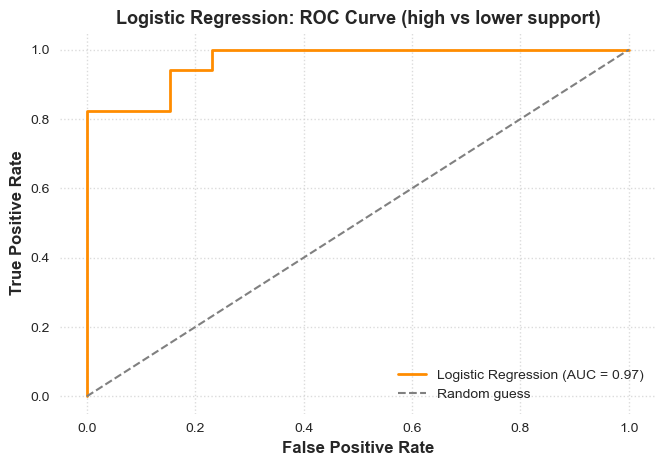

In [227]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Predicted probabilities for class 1 (high support)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)

sns.set_style("white")
fig, ax = plt.subplots(figsize=(7, 5))

# Main ROC line
ax.plot(fpr, tpr, color="darkorange", linewidth=2, label=f"Logistic Regression (AUC = {auc_lr:.2f})")

# Diagonal baseline
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1.5, label="Random guess")

ax.set_xlabel("False Positive Rate", fontsize=12, fontweight="bold")
ax.set_ylabel("True Positive Rate", fontsize=12, fontweight="bold")
ax.set_title("Logistic Regression: ROC Curve (high vs lower support)", fontsize=13, fontweight="bold")
ax.grid(True, linestyle=":", color="lightgray", alpha=0.8)
ax.legend(loc="lower right", fontsize=10)

plt.tight_layout()
plt.show()




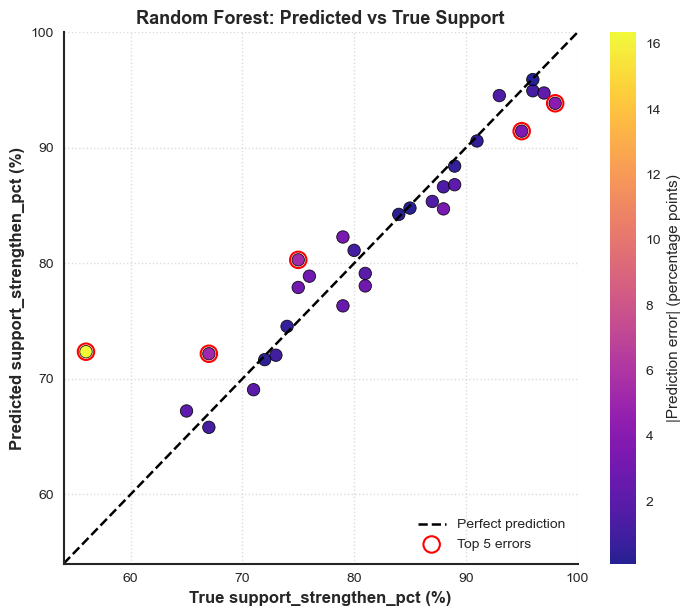

In [216]:
y_true = np.array(y_test)
y_rf   = np.array(y_pred_rf)
errors_rf = np.abs(y_true - y_rf)

min_val = min(y_true.min(), y_rf.min()) - 2
max_val = max(y_true.max(), y_rf.max()) + 2
lims = [min_val, max_val]

sns.set_style("white")
fig, ax = plt.subplots(figsize=(7.5, 6.5))

ax.spines["bottom"].set_linewidth(1.5)
ax.spines["left"].set_linewidth(1.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.plot(lims, lims, "--", color="black", linewidth=1.8, label="Perfect prediction")

scatter = ax.scatter(
    y_true,
    y_rf,
    c=errors_rf,
    cmap="plasma",
    s=80,
    edgecolor="black",
    linewidth=0.6,
    alpha=0.9
)

top5_idx = np.argsort(errors_rf)[-5:]
ax.scatter(
    y_true[top5_idx],
    y_rf[top5_idx],
    facecolors="none",
    edgecolors="red",
    s=140,
    linewidth=1.5,
    label="Top 5 errors"
)

cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("|Prediction error| (percentage points)", fontsize=11)

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("True support_strengthen_pct (%)", fontsize=12, fontweight="bold")
ax.set_ylabel("Predicted support_strengthen_pct (%)", fontsize=12, fontweight="bold")
ax.set_title("Random Forest: Predicted vs True Support", fontsize=13, fontweight="bold")

ax.grid(True, which="both", linestyle=":", color="lightgray", alpha=0.8)
ax.legend(loc="lower right", fontsize=10)

plt.tight_layout()
plt.show()


In [228]:
import pandas as pd
from sklearn.metrics import roc_auc_score

# Probabilities for AUC
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]
y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

auc_lr = roc_auc_score(y_test, y_proba_lr)
auc_rf = roc_auc_score(y_test, y_proba_rf)

# Build comparison table
results_clf = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest (Classifier)"],
    "Accuracy": [acc_lr, acc_rf],
    "F1 (class 1)": [f1_lr, f1_rf],
    "AUC": [auc_lr, auc_rf]
})

print(results_clf)


                        Model  Accuracy  F1 (class 1)       AUC
0         Logistic Regression  0.866667      0.882353  0.968326
1  Random Forest (Classifier)  0.833333      0.864865  0.945701


In [211]:
# From df_pivot (147 × 74, with support_strengthen_pct already defined)

# numeric columns = all except grouping fields
num_cols = [c for c in df_pivot.columns if c not in ["Country", "Age", "Education"]]

# aggregate to one row per country
df_country = df_pivot.groupby("Country")[num_cols].mean(numeric_only=True).reset_index()

print(df_country.shape)
df_country.head()




(65, 72)


Q_R,Country,Big businesses performance | Don't know,Big businesses performance | Neither well nor badly,Big businesses performance | Somewhat badly,Big businesses performance | Somewhat well,Big businesses performance | Very badly,Big businesses performance | Very well,Countries working together | Don't know,Countries working together | It doesn't matter - no country should work on climate change,Countries working together | No - they should work separately,Countries working together | Yes - they should work together despite their disagreements,Country performance | Don't know,Country performance | Neither well nor badly,Country performance | Somewhat badly,Country performance | Somewhat well,Country performance | Very badly,Country performance | Very well,Effects on big decisions | A little,Effects on big decisions | A lot,Effects on big decisions | Don't know,Effects on big decisions | Not at all,Extreme weather experience | About the same as usual,Extreme weather experience | Better than usual,Extreme weather experience | Don't know,Extreme weather experience | Worse than usual,Protect and restore nature | A little,Protect and restore nature | A lot,Protect and restore nature | Don't know,Protect and restore nature | Not at all,Protection from extreme weather | About the same as now,Protection from extreme weather | Don't know,Protection from extreme weather | Less protection,Protection from extreme weather | More protection,Renewable energy transition | Don't know,Renewable energy transition | Not at all,Renewable energy transition | Slowly,Renewable energy transition | Somewhat quickly,Renewable energy transition | Very quickly,Rich countries helping poor | About the same as now,Rich countries helping poor | Don't know,Rich countries helping poor | Less help,Rich countries helping poor | More help,Strengthening commitments | Don't know,Strengthening commitments | Keep them the same,support_strengthen_pct,Strengthening commitments | Weaken,Teaching about climate change | About the same as now,Teaching about climate change | Don't know,Teaching about climate change | Less,Teaching about climate change | More,Thinking about climate change | A few times a year,Thinking about climate change | Daily,Thinking about climate change | Don't know,Thinking about climate change | Never,Thinking about climate change | Weekly,Who has had most impact | Big business,Who has had most impact | Campaigners and activists,Who has had most impact | Don't know,Who has had most impact | Faith and community leaders,Who has had most impact | Government,Who has had most impact | The European Union (EU),Who has had most impact | The United Nations,Worry compared to last year | About the same,Worry compared to last year | Don't know,Worry compared to last year | Less worried,Worry compared to last year | More worried,Worry for next generation | Don't know,Worry for next generation | Extremely,Worry for next generation | Not at all,Worry for next generation | Not very,Worry for next generation | Somewhat,Worry for next generation | Very
0,Afghanistan,8.000000,18.0,10.500000,24.500000,15.000000,23.500000,2.000000,0.500000,4.000000,94.000000,11.500000,21.500000,8.500000,25.000000,17.000000,17.000000,17.500000,73.000000,3.000000,6.500000,22.000000,14.000000,11.0,52.500000,5.500000,91.500000,2.000000,1.500000,6.0,1.500000,2.5,90.000000,10.500000,2.500000,41.500000,10.000000,35.000000,2.500000,0.000000,1.000000,96.500000,8.5,13.500000,75.500000,2.000000,6.000000,0.500000,1.500000,91.500000,6.500000,56.000000,3.000000,6.000000,28.500000,6.500000,2.000000,30.500000,3.500000,23.0,0.0,33.500000,7.000000,1.500000,11.000000,80.500000,4.500000,32.500000,3.500000,1.500000,20.500000,37.500000
1,Algeria,22.500000,37.0,16.500000,10.500000,11.500000,2.000000,2.000000,1.500000,11.500000,84.500000,10.000000,43.500000,16.500000,15.000000,9.500000,5.500000,23.500000,47.500000,0.500000,28.000000,18.500000,8.000000,1.0,73.000000,3.500000,94.500000,0.500000,2.000000,5.0,1.000

In [221]:
# Feature importances from Random Forest (after rf_reg is fitted)
importances = rf_reg.feature_importances_
feature_names = X.columns

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("Top 15 features:")
feat_imp.head(15)


Top 15 features:


,feature,importance
42,Strengthening commitments | Keep them the same,0.456299
31,Protection from extreme weather | More protection,0.185083
43,Strengthening commitments | Weaken,0.117747
28,Protection from extreme weather | About the sa...,0.031510
40,Rich countries helping poor | More help,0.014929
20,Extreme weather experience | About the same as...,0.013119
41,Strengthening commitments | Don't know,0.011299
23,Extreme weather experience | Worse than usual,0.010997
47,Teaching about climate change | More,0.008100
33,Renewable energy transition | Not at all,0.007943


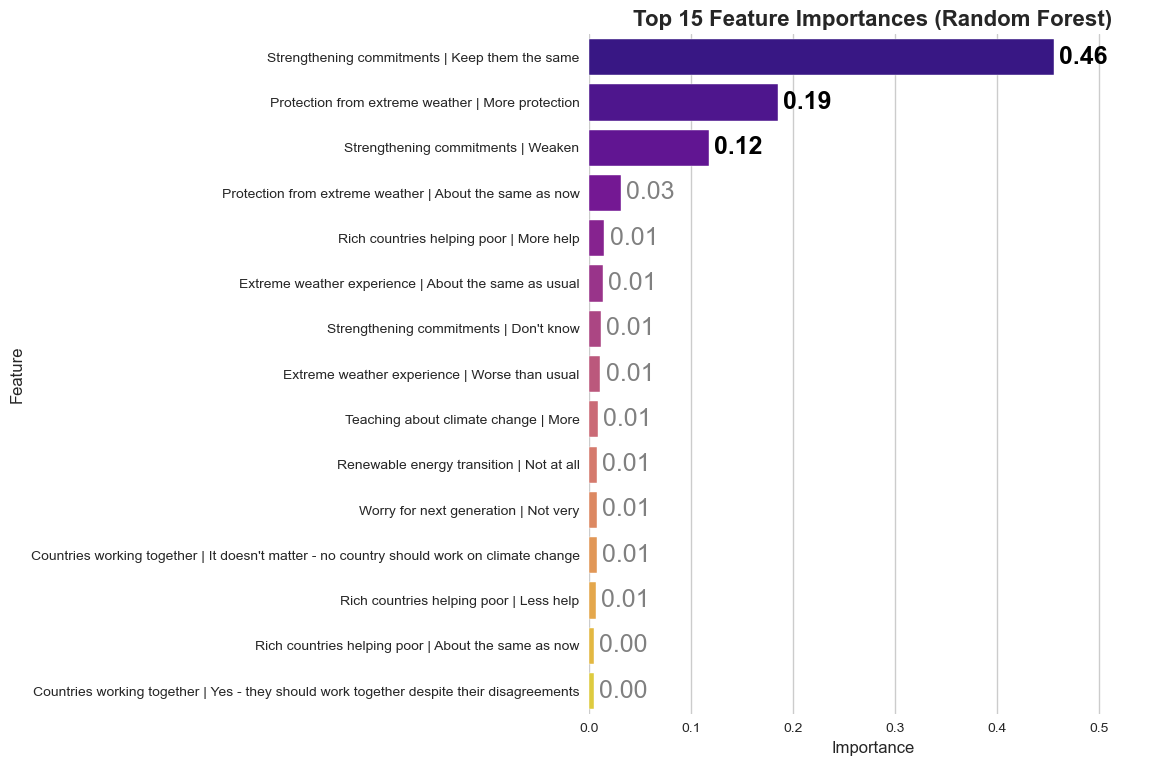

In [222]:
import matplotlib.pyplot as plt
import seaborn as sns

top_features = feat_imp.head(15).copy()

plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Shiny violet-style colours
colors = sns.color_palette("plasma", n_colors=15)

barplot = sns.barplot(
    x="importance",
    y="feature",
    data=top_features,
    hue="feature",
    dodge=False,
    palette=colors,
    legend=False
)

for i, (value, feature) in enumerate(zip(top_features["importance"], top_features["feature"])):
    if i < 3:
        barplot.text(
            value + 0.005, i, f"{value:.2f}",
            color="black", fontweight="bold", va="center"
        )
    else:
        barplot.text(
            value + 0.005, i, f"{value:.2f}",
            color="gray", va="center"
        )

plt.title("Top 15 Feature Importances (Random Forest)", fontsize=16, fontweight="bold")
plt.xlabel("Importance", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.xlim(0, top_features["importance"].max() + 0.1)

plt.tight_layout()
plt.show()


In [212]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Step: Prepare data for clustering
clust_features = [c for c in df_country.columns if c != "Country"]
X_clust_raw = df_country[clust_features].copy()

# Standardise all attitude variables
scaler = StandardScaler()
X_clust = scaler.fit_transform(X_clust_raw)

# K-means with k = 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_clust)

df_country["cluster"] = labels
df_country[["Country", "cluster"]].head()


Q_R,Country,cluster
0,Afghanistan,2
1,Algeria,2
2,Argentina,0
3,Australia,1
4,Bangladesh,2


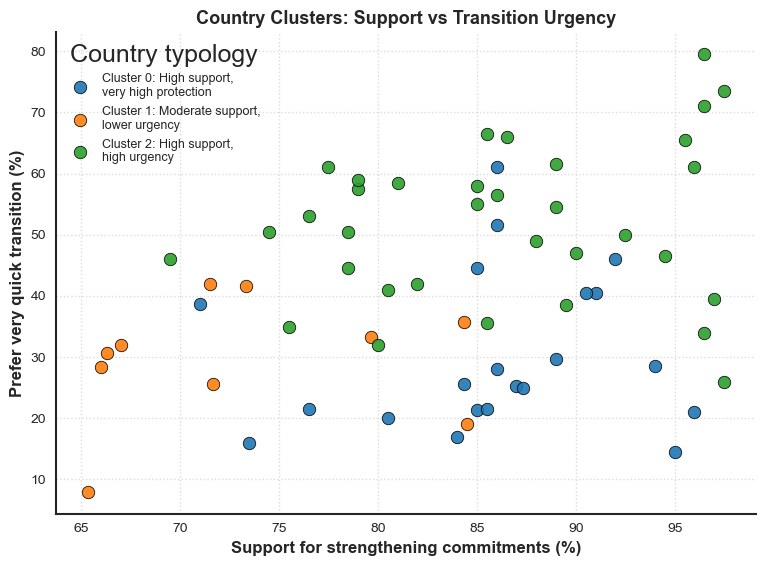

In [219]:
import matplotlib.pyplot as plt
import seaborn as sns

x_var = "support_strengthen_pct"
y_var = "Renewable energy transition | Very quickly"

sns.set_style("white")
fig, ax = plt.subplots(figsize=(8, 6))

ax.spines["bottom"].set_linewidth(1.5)
ax.spines["left"].set_linewidth(1.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Meaningful labels for clusters
cluster_labels = {
    0: "Cluster 0: High support,\nvery high protection",
    1: "Cluster 1: Moderate support,\nlower urgency",
    2: "Cluster 2: High support,\nhigh urgency"
}

palette = {0: "tab:blue", 1: "tab:orange", 2: "tab:green"}

for cl in sorted(df_country["cluster"].unique()):
    mask = df_country["cluster"] == cl
    ax.scatter(
        df_country.loc[mask, x_var],
        df_country.loc[mask, y_var],
        s=80,
        color=palette[cl],
        edgecolor="black",
        linewidth=0.6,
        alpha=0.9,
        label=cluster_labels[cl]   # legend will explain blue / orange / green
    )

ax.set_xlabel("Support for strengthening commitments (%)", fontsize=12, fontweight="bold")
ax.set_ylabel("Prefer very quick transition (%)", fontsize=12, fontweight="bold")
ax.set_title("Country Clusters: Support vs Transition Urgency", fontsize=13, fontweight="bold")

ax.grid(True, which="both", linestyle=":", color="lightgray", alpha=0.8)
ax.legend(title="Country typology", fontsize=9)

plt.tight_layout()
plt.show()



In [213]:
key_vars = [
    "support_strengthen_pct",
    "Renewable energy transition | Very quickly",
    "Protection from extreme weather | More protection",
    "Worry for next generation | Very",
    "Who has had most impact | Government"
]

cluster_summary = df_country.groupby("cluster")[key_vars].mean()
cluster_summary


Q_R,support_strengthen_pct,Renewable energy transition | Very quickly,Protection from extreme weather | More protection,Worry for next generation | Very,Who has had most impact | Government
cluster,,,,,
0,85.960317,30.373016,90.412698,43.047619,38.539683
1,72.966667,29.633333,66.516667,29.300000,33.183333
2,86.205882,51.911765,86.867647,35.926471,42.816176
